In [1]:
import pandas as pd
import datetime as dtm
from chinese_calendar import is_holiday
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import distributions
import powerlaw
import numpy as np
import seaborn as sns
from h3 import h3
from MoranI import moranI
from scipy.stats import kstest, gaussian_kde
import matplotlib.ticker as ticker

In [2]:
res = 9
work_path = os.path.abspath(os.getcwd()+os.path.sep+"..")
data_path = os.path.join(work_path,'Results','Lianyungang','RES=%s' % res)

all_strength = pd.read_csv(os.path.join(data_path,'all_strength.csv'))
all_strength.date = pd.to_datetime(all_strength.date)
all_strength['Holiday'] =  all_strength.date.apply(lambda x: is_holiday(x))

In [7]:
sele_strength = all_strength.loc[(all_strength['date'].dt.month==6)]
day_fit = []
for dd in sele_strength['date'].value_counts().to_frame().index:
    day_strength = sele_strength.loc[sele_strength['date']==dd]
    s = day_strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata/sum(ydata)
    def func(x,alpha,a):
        pl = np.power(x,-alpha)
        return pl*a
    def func2(x,alpha,beta,a):
        pl = np.power(x,-alpha)
        ex = np.exp(-x/beta)
        return pl*ex*a
    popt_l, pcov_l = curve_fit(func, xdata, ydata,p0=[0.5,0.05], maxfev = 5108000)
    popt_t, pcov_t = curve_fit(func2, xdata, ydata,p0=[0.5,100,0.5], maxfev = 5108000)
    ks_l = kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l)))
    ks_t = kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t)))
    day_fit.append([dd,popt_l[0],ks_l[0],ks_l[1],popt_t[0],popt_t[1],ks_t[0],ks_t[1]])

pd.DataFrame(day_fit).to_csv(os.path.join(data_path,'LYGfit.csv'))


C:\Users\Tlab\AppData\Local\Temp\ipykernel_10948\444083142.py:14: RuntimeWarning: overflow encountered in exp
  ex = np.exp(-x/beta)


In [10]:
pd.DataFrame(day_fit)

,0,1,2,3,4,5,6,7
0,2022-06-16,0.538586,0.220339,1.971382e-05,0.250769,63.932216,0.343220,1.012679e-12
1,2022-06-21,0.563765,0.240175,3.315778e-06,0.292820,63.403031,0.336245,7.256241e-12
2,2022-06-20,0.572738,0.238298,2.897672e-06,0.366988,84.229618,0.310638,2.041147e-10
3,2022-06-08,0.552354,0.251046,5.046197e-07,0.233061,52.442912,0.418410,3.982888e-19
4,2022-06-17,0.562085,0.220339,1.971382e-05,0.341788,83.212969,0.292373,2.690103e-09
5,2022-06-07,0.564925,0.247899,7.871470e-07,0.299499,63.913802,0.361345,3.351119e-14
6,2022-06-15,0.521727,0.230453,4.544085e-06,0.193615,55.723519,0.395062,2.565227e-17
7,2022-06-10,0.527088,0.229508,4.796749e-06,0.233115,63.501008,0.381148,3.503528e-16
8,2022-06-22,0.559071,0.240175,3.315778e-06,0.287304,62.782890,0.349345,8.550193e-13
9,2022-06-12,0.541235,0.247748,2.162407e-06,0.169669,40.932965,0.445946,3.043501e-20


In [13]:
daily = all_strength[all_strength['date']=='2022-06-08']

s = daily['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
xdata = s['index'].values
ydata = s['strength_values'].values
ydata = ydata
ydata = ydata/sum(ydata)
def func(x,alpha,a):
    pl = np.power(x,-alpha)
    return pl*a
def func2(x,alpha,beta,a):
    pl = np.power(x,-alpha)
    ex = np.exp(-x/beta)
    return pl*ex*a
popt_l, pcov_l = curve_fit(func, xdata, ydata, p0=[0.5,0.05], maxfev = 5108000)
popt_t, pcov_t = curve_fit(func2, xdata, ydata,p0=[0.5,100,0.05], maxfev = 5108000)
print(popt_l)
print(popt_t)

[0.55235356 0.04803104]
[2.33059517e-01 5.24425574e+01 3.73786782e-02]


In [4]:

from sklearn.metrics import r2_score
 
# y_true为实际观测值，y_pred为模型预测值
r2_l = r2_score(ydata, func(xdata, *popt_l))
r2_t = r2_score(ydata, func2(xdata, *popt_t))
print("ppl r2: ", r2_l)
print("etpl r2: ", r2_t)

ppl r2:  0.7521269057841392
etpl r2:  0.8340049430308563


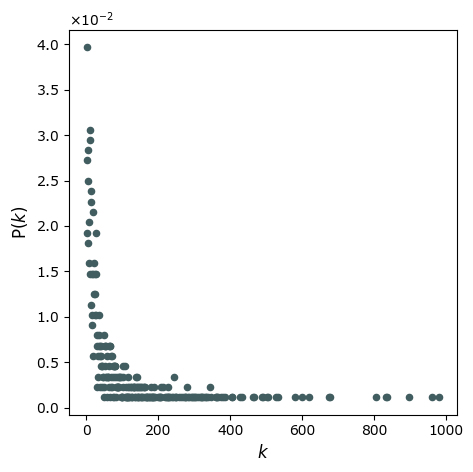

In [4]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5.0, 5)
plt.scatter(xdata, ydata, s= 20, color='#425d5f', label='Data')
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
ax = plt.gca()
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2,-2))
ax.yaxis.set_major_formatter(formatter)
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\LYG1.tif")

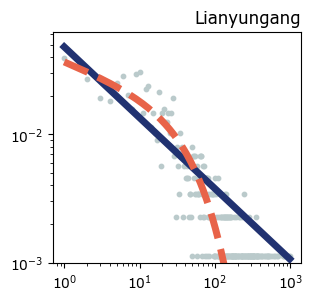

In [5]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (3.2,3)
plt.scatter(xdata, ydata, s= 10, color='#bacacb', alpha=1)
plt.plot(xdata, func(xdata, *popt_l), '#213271', lw=5, label=r'$Ck^{-\alpha}$')
plt.plot(xdata, func2(xdata, *popt_t),'#e86349', lw=5, linestyle = "--", label=r'$Ck^{-\alpha}e^{-\frac{k}{\lambda}}$')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3,10**-1.2))
plt.title('Lianyungang',loc='right')
#plt.legend(loc='upper right',frameon =True,fontsize = 10)

# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\LYG2.tif")

In [5]:

print(popt_l)
print(popt_t)
print(kstest(np.cumsum(ydata),np.cumsum(func(xdata, *popt_l))))
print(kstest(np.cumsum(ydata),np.cumsum(func2(xdata, *popt_t))))

[0.55235356 0.04803104]
[2.33059517e-01 5.24425574e+01 3.73786782e-02]
KstestResult(statistic=0.2510460251046025, pvalue=5.046197159494725e-07, statistic_location=0.9999999999999972, statistic_sign=1)
KstestResult(statistic=0.41841004184100417, pvalue=3.9828880808217334e-19, statistic_location=0.8729389766508207, statistic_sign=-1)


In [14]:
c1 = len(np.where(np.cumsum(ydata)<0.50)[0])
c2 = len(np.where(np.cumsum(ydata)<0.55)[0])
c3 = len(np.where(np.cumsum(ydata)<0.60)[0])
c4 = len(np.where(np.cumsum(ydata)<0.65)[0])
c5 = len(np.where(np.cumsum(ydata)<0.70)[0])
c6 = len(np.where(np.cumsum(ydata)<0.75)[0])
c7 = len(np.where(np.cumsum(ydata)<0.80)[0])
c8 = len(np.where(np.cumsum(ydata)<0.85)[0])
c9 = len(np.where(np.cumsum(ydata)<0.90)[0])
c0 = len(np.where(np.cumsum(ydata)<0.95)[0])
vline = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]
print(c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata))

27 34 43 54 65 80 100 126 158 195 239


In [15]:
def color_vector(start_color, end_color, num_steps):
    # 计算每一阶的颜色
    colors = []
    for i in range(num_steps):
        r = int(start_color[0] - (start_color[0] - end_color[0]) / (num_steps - 1) * i)
        g = int(start_color[1] - (start_color[1] - end_color[1]) / (num_steps - 1) * i)
        b = int(start_color[2] - (start_color[2] - end_color[2]) / (num_steps - 1) * i)
        color = (r, g, b)
        colors.append(color)
    
    # 输出每一阶颜色的 16 进制表示
    hex_colors = []
    for color in colors:
        hex_color = "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])
        hex_colors.append(hex_color)
    
    # 返回颜色向量
    return hex_colors

In [16]:
# def puring_fit(strength,c):
#     strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
#     strength = strength.iloc[:c]
    
#     ydata = strength['strength_values'].values
#     xdata = strength['index'].values
#     ydata = ydata/sum(ydata)

#     return xdata, ydata

def puring_fit(strength,c):
    strength = strength.sort_values(by='index', ascending=True).reset_index(drop=True)
    
    ydata = strength['strength_values'].values
    xdata = strength['index'].values
    ydata = ydata/sum(ydata)

    xdata = xdata[:c]
    ydata = ydata[:c]


    return xdata, ydata

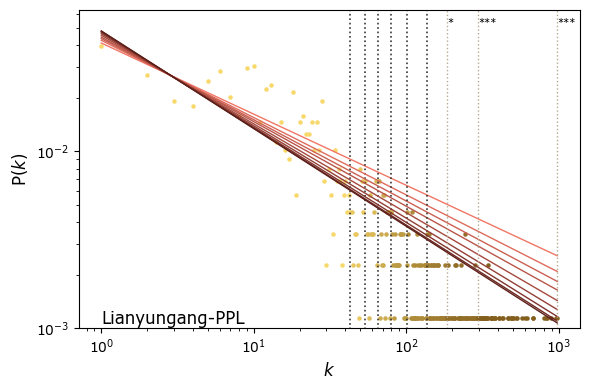

In [18]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((241,118,102), (92,30,25), len(vline))

xinpos = 10**-1.3

ppl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    popt, pcov = curve_fit(func, x_data, y_data, p0=[0.5,0.05], maxfev = 5108000)
    y_fit = func(xdata, *popt)
    ks = kstest(np.cumsum(ydata[:c]),np.cumsum(y_fit[:c]))

    pl = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [popt[0]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    ppl = pd.concat([ppl,pl])

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")

    #点
    if posi == 0:
        plt.scatter(xdata[:c], ydata[:c], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])

plt.text(xdata.min(),10**-3,"Lianyungang-PPL", ha='left', va='bottom', fontsize=12)

# plt.title('Bus-Lianyungang',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3,10**-1.2))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\LYGppl.tif")

In [19]:
ppl

,puring,et_alpha,et_d,et_pvalue
0,0,0.402433,0.116279,9.377161e-01
0,1,0.437307,0.148148,5.984843e-01
0,2,0.459446,0.138462,5.651455e-01
0,3,0.478483,0.137500,4.382623e-01
0,4,0.502037,0.130000,3.681878e-01
0,5,0.522101,0.126984,2.623398e-01
0,6,0.537750,0.164557,2.756631e-02
0,7,0.547811,0.205128,5.266064e-04
0,8,0.552354,0.251046,5.046197e-07


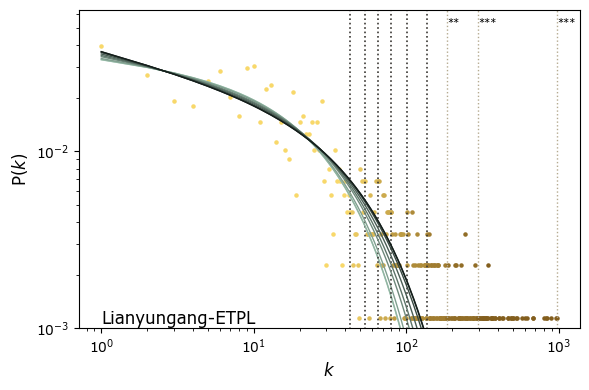

In [20]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

vline = [c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]

lyg_dot_clr = color_vector((248,216,106), (131,94,29), len(vline))
lyg_lne_clr = color_vector((164,202,182), (20,30,27), len(vline))

etpl = pd.DataFrame([])

for posi in range(len(vline)):
    c = vline[posi]
    x_data, y_data = puring_fit(s,c)
    poptt, pcovv = curve_fit(func2, x_data, y_data, p0=[0.3,60,0.01], maxfev = 5108000)
    y_fit = func2(xdata, *poptt)
    ks = kstest(np.cumsum(y_data[:c]),np.cumsum(y_fit[:c]))
    # print(poptt)

    et = pd.DataFrame({
        'puring': [posi],
        'et_alpha': [poptt[0]],
        'et_lambda': [poptt[1]],
        'et_d': [ks[0]],
        'et_pvalue': [ks[1]]
    })

    etpl = pd.concat([etpl,et],ignore_index=True)

    #虚线
    if ks[1] < 0.05:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-1, lw=1, ls=":",color="#b5aa90")
        if ks[1] < 0.001:
            plt.text(x_data.max(),xinpos,"***", ha='left', va='bottom',fontsize=7)
        elif (ks[1] >= 0.001)&(ks[1] < 0.01):
            plt.text(x_data.max(),xinpos,"**", ha='left', va='bottom',fontsize=7)
        else:
            plt.text(x_data.max(),xinpos,"*", ha='left', va='bottom',fontsize=7)
    else:
        plt.vlines(x=x_data.max(), ymin=10e-5,ymax=10e-2, lw=1.2, ls=":",color="#393733")
        
    
    #点
    if posi == 0:
        plt.scatter(xdata[:vline[posi]], ydata[:vline[posi]], s= 5, color=lyg_dot_clr[posi])
    else:
        plt.scatter(xdata[vline[posi-1]:vline[posi]], ydata[vline[posi-1]:vline[posi]], s= 5, color=lyg_dot_clr[posi])

    #线
    plt.plot(xdata, y_fit, lw=1, color=lyg_lne_clr[posi])

plt.text(xdata.min(),10**-3,"Lianyungang-ETPL", ha='left', va='bottom', fontsize=12)

# plt.title('Bus-Lianyungang',loc='right')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10**-3,10**-1.2))
plt.xlabel('$k$',fontsize=12)
plt.ylabel('P$(k)$',fontsize=12)
# plt.legend(loc='upper right')
plt.tight_layout()
# plt.show()
plt.savefig(r"D:\Papers\202209_demand_analyse\pic\bus\LYGetpl.tif")


In [21]:
etpl

,puring,et_alpha,et_lambda,et_d,et_pvalue
0,0,0.095166,29.463328,0.069767,9.999670e-01
1,1,0.098129,29.659628,0.074074,9.987376e-01
2,2,0.116868,31.915769,0.061538,9.997574e-01
3,3,0.150045,36.545808,0.062500,9.979305e-01
4,4,0.170924,39.902417,0.070000,9.684099e-01
5,5,0.195260,44.281658,0.103175,5.153841e-01
6,6,0.218802,49.161618,0.183544,9.630345e-03
7,7,0.231296,52.026120,0.292308,9.498135e-08
8,8,0.233056,52.441744,0.418410,3.982888e-19


In [14]:
popt1, pcov1 = curve_fit(func, xdata[:c1], ydata[:c1], p0=[0.1,0.01], maxfev = 5108000)
popt2, pcov2 = curve_fit(func, xdata[:c2], ydata[:c2], p0=[0.1,0.01], maxfev = 5180000)
popt3, pcov3 = curve_fit(func, xdata[:c3], ydata[:c3], p0=[0.1,0.01], maxfev = 5108000)
popt4, pcov4 = curve_fit(func, xdata[:c4], ydata[:c4], p0=[0.1,0.01], maxfev = 5108000)
popt5, pcov5 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.1,0.01], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c5], ydata[:c5], p0=[0.1,0.01], maxfev = 5108000)
popt6, pcov6 = curve_fit(func, xdata[:c6], ydata[:c6], p0=[0.1,0.01], maxfev = 5108000)
popt7, pcov7 = curve_fit(func, xdata[:c7], ydata[:c7], p0=[0.1,0.01], maxfev = 5108000)
popt8, pcov8 = curve_fit(func, xdata[:c8], ydata[:c8], p0=[0.1,0.01], maxfev = 5108000)
popt9, pcov9 = curve_fit(func, xdata[:c9], ydata[:c9], p0=[0.1,0.01], maxfev = 5108000)
popt0, pcov0 = curve_fit(func, xdata[:c0], ydata[:c0], p0=[0.1,0.01], maxfev = 5108000)
np.vstack((popt_l,popt0,popt9,popt8,popt7,popt6,popt5,popt4,popt3))

array([[0.55235356, 0.04803104],
       [0.54780098, 0.04776893],
       [0.53774205, 0.04723417],
       [0.52210106, 0.04644904],
       [0.50202972, 0.04547491],
       [0.47848813, 0.04437365],
       [0.45944477, 0.04350757],
       [0.43730807, 0.0425355 ],
       [0.40243649, 0.04105007]])

In [15]:
popt11, pcov11 = curve_fit(func2, xdata[:c1], ydata[:c1], p0=[0.1,50,0.01], maxfev = 5108000)
popt22, pcov22 = curve_fit(func2, xdata[:c2], ydata[:c2], p0=[0.1,50,0.01], maxfev = 5180000)
popt33, pcov33 = curve_fit(func2, xdata[:c3], ydata[:c3], p0=[0.1,50,0.01], maxfev = 5108000)
popt44, pcov44 = curve_fit(func2, xdata[:c4], ydata[:c4], p0=[0.1,50,0.01], maxfev = 5108000)
popt55, pcov55 = curve_fit(func2, xdata[:c5], ydata[:c5], p0=[0.1,50,0.01], maxfev = 5108000)
popt66, pcov66 = curve_fit(func2, xdata[:c6], ydata[:c6], p0=[0.1,50,0.01], maxfev = 5108000)
popt77, pcov77 = curve_fit(func2, xdata[:c7], ydata[:c7], p0=[0.1,50,0.01], maxfev = 5108000)
popt88, pcov88 = curve_fit(func2, xdata[:c8], ydata[:c8], p0=[0.1,50,0.01], maxfev = 5108000)
popt99, pcov99 = curve_fit(func2, xdata[:c9], ydata[:c9], p0=[0.1,50,0.01], maxfev = 5108000)
popt00, pcov00 = curve_fit(func2, xdata[:c0], ydata[:c0], p0=[0.1,50,0.01], maxfev = 5108000)
np.vstack((popt_t,popt00,popt99,popt88,popt77,popt66,popt55,popt44,popt33))

array([[2.33059517e-01, 5.24425574e+01, 3.73786782e-02],
       [2.31332439e-01, 5.20347588e+01, 3.73302034e-02],
       [2.18800814e-01, 4.91612636e+01, 3.69895361e-02],
       [1.95255175e-01, 4.42808486e+01, 3.63798903e-02],
       [1.70923850e-01, 3.99024343e+01, 3.57828588e-02],
       [1.50048426e-01, 3.65461796e+01, 3.53058509e-02],
       [1.16858358e-01, 3.19149751e+01, 3.46030954e-02],
       [9.81336756e-02, 2.96599256e+01, 3.42296643e-02],
       [9.51687630e-02, 2.94634230e+01, 3.41446697e-02]])

In [16]:
def color_vector(start_color, end_color, num_steps):
    # 计算每一阶的颜色
    colors = []
    for i in range(num_steps):
        r = int(start_color[0] - (start_color[0] - end_color[0]) / (num_steps - 1) * i)
        g = int(start_color[1] - (start_color[1] - end_color[1]) / (num_steps - 1) * i)
        b = int(start_color[2] - (start_color[2] - end_color[2]) / (num_steps - 1) * i)
        color = (r, g, b)
        colors.append(color)
    
    # 输出每一阶颜色的 16 进制表示
    hex_colors = []
    for color in colors:
        hex_color = "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])
        hex_colors.append(hex_color)
    
    # 返回颜色向量
    return hex_colors


In [17]:
print(kstest(ydata[:c3],func(xdata[:c3], *popt3)))
print(kstest(ydata[:c4],func(xdata[:c4], *popt4)))
print(kstest(ydata[:c5],func(xdata[:c5], *popt5)))
print(kstest(ydata[:c6],func(xdata[:c6], *popt6)))
print(kstest(ydata[:c7],func(xdata[:c7], *popt7)))
print(kstest(ydata[:c8],func(xdata[:c8], *popt8)))
print(kstest(ydata[:c9],func(xdata[:c9], *popt9)))
print(kstest(ydata[:c0],func(xdata[:c0], *popt0)))
print(kstest(ydata,func(xdata, *popt_l)))

KstestResult(statistic=0.3488372093023256, pvalue=0.010186169919027715, statistic_location=0.007936507936507936, statistic_sign=1)
KstestResult(statistic=0.42592592592592593, pvalue=8.927466488509318e-05, statistic_location=0.006802721088435374, statistic_sign=1)
KstestResult(statistic=0.38461538461538464, pvalue=0.00011223017638114333, statistic_location=0.005668934240362812, statistic_sign=1)
KstestResult(statistic=0.4, pvalue=4.179439146820865e-06, statistic_location=0.0045351473922902496, statistic_sign=1)
KstestResult(statistic=0.48, pvalue=8.448372017533173e-11, statistic_location=0.0045351473922902496, statistic_sign=1)
KstestResult(statistic=0.5238095238095238, pvalue=3.80998724945765e-16, statistic_location=0.003401360544217687, statistic_sign=1)
KstestResult(statistic=0.4936708860759494, pvalue=7.633896731086231e-18, statistic_location=0.0022675736961451248, statistic_sign=1)
KstestResult(statistic=0.5282051282051282, pvalue=3.1658515437118907e-25, statistic_location=0.002267

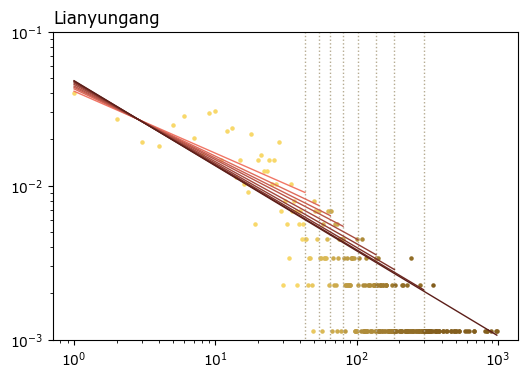

In [29]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((241,118,102), (92,30,25), 9)

for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func(xdata[:c1], *popt1), lw=1, color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func(xdata[:c2], *popt2), lw=1, color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func(xdata[:c3], *popt3), lw=1, color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func(xdata[:c4], *popt4), lw=1, color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func(xdata[:c5], *popt5), lw=1, color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func(xdata[:c6], *popt6), lw=1, color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func(xdata[:c7], *popt7), lw=1, color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func(xdata[:c8], *popt8), lw=1, color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func(xdata[:c9], *popt9), lw=1, color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func(xdata[:c0], *popt0), lw=1, color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func(xdata, *popt_l), lw=1, color=lyg_lne_clr[8], label = ' 0%')

#plt.vlines(x=c1,ymin=10e-4,ymax=10e-2,lw=2, ls=":",color="#393733")

plt.title('Lianyungang',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-4,10e-2))
# plt.legend(loc='upper right')
plt.show()

In [28]:
# print(kstest(ydata[:c1],func2(xdata[:c1], *popt11)))
# print(kstest(ydata[:c2],func2(xdata[:c2], *popt22)))
print(kstest(ydata[:c3],func2(xdata[:c3], *popt33)))
print(kstest(ydata[:c4],func2(xdata[:c4], *popt44)))
print(kstest(ydata[:c5],func2(xdata[:c5], *popt55)))
print(kstest(ydata[:c6],func2(xdata[:c6], *popt66)))
print(kstest(ydata[:c7],func2(xdata[:c7], *popt77)))
print(kstest(ydata[:c8],func2(xdata[:c8], *popt88)))
print(kstest(ydata[:c9],func2(xdata[:c9], *popt99)))
print(kstest(ydata[:c0],func2(xdata[:c0], *popt00)))

KstestResult(statistic=0.18604651162790697, pvalue=0.45062270517842934, statistic_location=0.005668934240362812, statistic_sign=1)
KstestResult(statistic=0.14814814814814814, pvalue=0.5984842563735271, statistic_location=0.003401360544217687, statistic_sign=1)
KstestResult(statistic=0.12307692307692308, pvalue=0.7126448984473942, statistic_location=0.003401360544217687, statistic_sign=1)
KstestResult(statistic=0.1, pvalue=0.8219389974333371, statistic_location=0.006802721088435374, statistic_sign=1)
KstestResult(statistic=0.1, pvalue=0.7020569828664881, statistic_location=0.0011337868480725624, statistic_sign=1)
KstestResult(statistic=0.15873015873015872, pvalue=0.08355418801016877, statistic_location=0.0011264554613871942, statistic_sign=-1)
KstestResult(statistic=0.2848101265822785, pvalue=4.736298532029058e-06, statistic_location=0.0011299594687396541, statistic_sign=-1)
KstestResult(statistic=0.41025641025641024, pvalue=4.5470550192066366e-15, statistic_location=0.00112940705739263

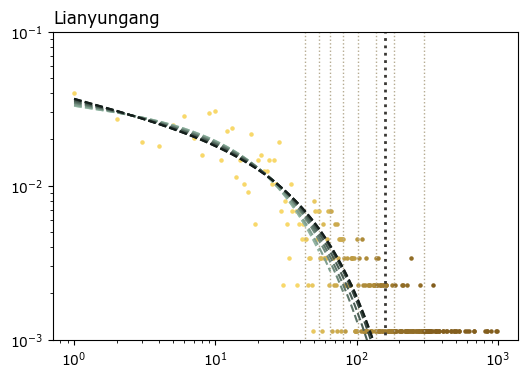

In [32]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (6, 4)

lyg_dot_clr = color_vector((248,216,106), (131,94,29), 9)
lyg_lne_clr = color_vector((164,202,182), (20,30,27), 9)



for v in range(2,10):
    plt.vlines(x=xdata[vline[v]-1], ymin=10e-5,ymax=10e-2, lw=1, ls=":",color="#b5aa90")

#plt.scatter(xdata[:c1], ydata[:c1], s= 5, color=lyg_dot_clr[0])
#plt.scatter(xdata[c1:c2], ydata[c1:c2], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[:c3], ydata[:c3], s= 5, color=lyg_dot_clr[0])
plt.scatter(xdata[c3:c4], ydata[c3:c4], s= 5, color=lyg_dot_clr[1])
plt.scatter(xdata[c4:c5], ydata[c4:c5], s= 5, color=lyg_dot_clr[2])
plt.scatter(xdata[c5:c6], ydata[c5:c6], s= 5, color=lyg_dot_clr[3])
plt.scatter(xdata[c6:c7], ydata[c6:c7], s= 5, color=lyg_dot_clr[4])
plt.scatter(xdata[c7:c8], ydata[c7:c8], s= 5, color=lyg_dot_clr[5])
plt.scatter(xdata[c8:c9], ydata[c8:c9], s= 5, color=lyg_dot_clr[6])
plt.scatter(xdata[c9:c0], ydata[c9:c0], s= 5, color=lyg_dot_clr[7])
plt.scatter(xdata[c0:], ydata[c0:], s= 5, color=lyg_dot_clr[8])

# plt.plot(xdata[:c1], func2(xdata[:c1], *popt11), ls="--", color=lyg_lne_clr[0], label = '50%')
# plt.plot(xdata[:c2], func2(xdata[:c2], *popt22), ls="--", color=lyg_lne_clr[1], label = '45%')
plt.plot(xdata[:c3], func2(xdata[:c3], *popt33), ls="--", color=lyg_lne_clr[0], label = '40%')
plt.plot(xdata[:c4], func2(xdata[:c4], *popt44), ls="--", color=lyg_lne_clr[1], label = '35%')
plt.plot(xdata[:c5], func2(xdata[:c5], *popt55), ls="--", color=lyg_lne_clr[2], label = '30%')
plt.plot(xdata[:c6], func2(xdata[:c6], *popt66), ls="--", color=lyg_lne_clr[3], label = '25%')
plt.plot(xdata[:c7], func2(xdata[:c7], *popt77), ls="--", color=lyg_lne_clr[4], label = '20%')
plt.plot(xdata[:c8], func2(xdata[:c8], *popt88), ls="--", color=lyg_lne_clr[5], label = '15%')
plt.plot(xdata[:c9], func2(xdata[:c9], *popt99), ls="--", color=lyg_lne_clr[6], label = '10%')
plt.plot(xdata[:c0], func2(xdata[:c0], *popt00), ls="--", color=lyg_lne_clr[7], label = ' 5%')
plt.plot(xdata, func2(xdata, *popt_t), ls="--", color=lyg_lne_clr[8], label = ' 0%')

plt.vlines(x=c9,ymin=10e-5,ymax=10e-2,lw=2, ls=":",color="#393733")

plt.title('Lianyungang',loc='left')
plt.xscale('log')
plt.yscale('log')
plt.ylim((10e-4,10e-2))
# plt.legend(loc='upper right')
plt.show()

In [8]:
sele_strength = all_strength.loc[(all_strength['date'].dt.month==6)]
day_fit = []
purning = [50,45,40,35,30,25,20,15,10,5,0]
for dd in sele_strength['date'].value_counts().to_frame().index:
    day_strength = sele_strength.loc[sele_strength['date']==dd]
    s = day_strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
    xdata = s['index'].values
    ydata = s['strength_values'].values
    ydata = ydata/sum(ydata)
    c1 = len(np.where(np.cumsum(ydata)<0.50)[0])
    c2 = len(np.where(np.cumsum(ydata)<0.55)[0])
    c3 = len(np.where(np.cumsum(ydata)<0.60)[0])
    c4 = len(np.where(np.cumsum(ydata)<0.65)[0])
    c5 = len(np.where(np.cumsum(ydata)<0.70)[0])
    c6 = len(np.where(np.cumsum(ydata)<0.75)[0])
    c7 = len(np.where(np.cumsum(ydata)<0.80)[0])
    c8 = len(np.where(np.cumsum(ydata)<0.85)[0])
    c9 = len(np.where(np.cumsum(ydata)<0.90)[0])
    c0 = len(np.where(np.cumsum(ydata)<0.95)[0])
    vline = [c1,c2,c3,c4,c5,c6,c7,c8,c9,c0,len(ydata)]
    for v in range(2,11):
        popt, pcov = curve_fit(func2, xdata[:vline[v]], ydata[:vline[v]],p0=[0.1,50,0.01], maxfev = 5108000)

        ks_t = kstest(ydata[:vline[v]],func2(xdata[:vline[v]], *popt))
        day_fit.append([dd,purning[v],popt[0],popt[1],ks_t[0],ks_t[1]])

df_fit = pd.DataFrame(day_fit)
df_fit.columns = ['Date','Pruning','Alpha','Lambda','d','p']

In [9]:
import scipy.stats

grouped_means = df_fit.groupby('Pruning')[['Alpha', 'Lambda']].mean().reset_index(drop=False)

def conf_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m-h, m+h

Alpha_conf_interval = df_fit.groupby('Pruning')[['Alpha']].apply(conf_interval).apply(pd.Series)
Alpha_conf_interval = Alpha_conf_interval.rename(columns={0: 'Lower_Alpha', 1: 'Upper_Alpha'})
Alpha_conf_interval['Lower_Alpha'] = Alpha_conf_interval['Lower_Alpha'].apply(lambda x:x[0])
Alpha_conf_interval['Upper_Alpha'] = Alpha_conf_interval['Upper_Alpha'].apply(lambda x:x[0])
Alpha_conf_interval = Alpha_conf_interval.reset_index(drop=False)
final_df = pd.merge(grouped_means, Alpha_conf_interval, on='Pruning')

Lambda_conf_interval = df_fit.groupby('Pruning')[['Lambda']].apply(conf_interval).apply(pd.Series)
Lambda_conf_interval = Lambda_conf_interval.rename(columns={0: 'Lower_Lambda', 1: 'Upper_Lambda'})
Lambda_conf_interval['Lower_Lambda'] = Lambda_conf_interval['Lower_Lambda'].apply(lambda x:x[0])
Lambda_conf_interval['Upper_Lambda'] = Lambda_conf_interval['Upper_Lambda'].apply(lambda x:x[0])
Lambda_conf_interval = Lambda_conf_interval.reset_index(drop=False)
final_df = pd.merge(final_df, Lambda_conf_interval, on='Pruning')
final_df = final_df[final_df['Pruning']<=40]

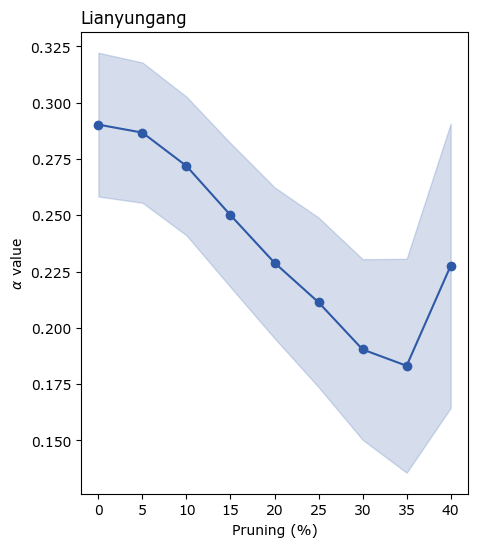

In [13]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5, 6)

alpha_clr = "#{:02x}{:02x}{:02x}".format(46, 89, 167)
lambda_clr = "#{:02x}{:02x}{:02x}".format(176, 69, 82)

plt.plot(final_df['Pruning'], final_df['Alpha'], marker='o', color=alpha_clr)

alpha_lower_ci = final_df['Lower_Alpha']
alpha_upper_ci = final_df['Upper_Alpha']

plt.fill_between(final_df['Pruning'], alpha_lower_ci, alpha_upper_ci, color=alpha_clr, alpha=0.2)

plt.title('Lianyungang',loc='left')
plt.xlabel('Pruning (%)')
plt.ylabel(r'$\alpha$ value')
plt.xticks(final_df['Pruning'][::1])
# plt.ylim(0.1,0.35)
plt.show()

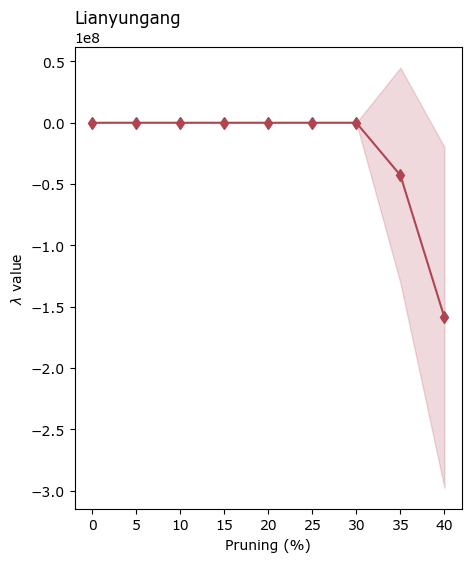

In [14]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (5, 6)

alpha_clr = "#{:02x}{:02x}{:02x}".format(46, 89, 167)
lambda_clr = "#{:02x}{:02x}{:02x}".format(176, 69, 82)

plt.plot(final_df['Pruning'], final_df['Lambda'], marker='d', color=lambda_clr)

alpha_lower_ci = final_df['Lower_Lambda']
alpha_upper_ci = final_df['Upper_Lambda']

plt.fill_between(final_df['Pruning'], alpha_lower_ci, alpha_upper_ci, color=lambda_clr, alpha=0.2)

plt.title('Lianyungang',loc='left')
plt.xlabel('Pruning (%)')
plt.ylabel(r'$\lambda$ value')
plt.xticks(final_df['Pruning'][::1])
# plt.ylim(32,67)
plt.show()

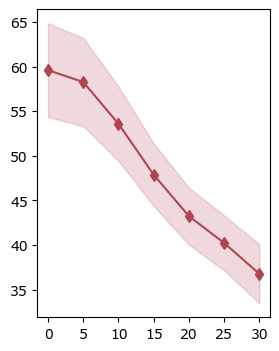

In [16]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (3, 4)

alpha_clr = "#{:02x}{:02x}{:02x}".format(46, 89, 167)
lambda_clr = "#{:02x}{:02x}{:02x}".format(176, 69, 82)

plt.plot(final_df.loc[:6,'Pruning'], final_df.loc[:6,'Lambda'], marker='d', color=lambda_clr)

alpha_lower_ci = final_df.loc[:6,'Lower_Lambda']
alpha_upper_ci = final_df.loc[:6,'Upper_Lambda']

plt.fill_between(final_df.loc[:6,'Pruning'], alpha_lower_ci, alpha_upper_ci, color=lambda_clr, alpha=0.2)

# plt.xlabel('Pruning (%)')
# plt.ylabel(r'$\lambda$ value')
plt.xticks(final_df['Pruning'][:7:1])
# plt.ylim(32,67)
plt.show()

In [11]:
s_date = dtm.datetime.strptime('20220601','%Y%m%d')
e_date = dtm.datetime.strptime('20220701','%Y%m%d')
strength = all_strength[(all_strength['date'] >= s_date ) & (all_strength['date'] < e_date)]
strength['date'] = strength['date'].apply(lambda x: dtm.datetime.strftime(x,'%m-%d'))

C:\Users\Tlab\AppData\Local\Temp\ipykernel_6652\3561102995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strength['date'] = strength['date'].apply(lambda x: dtm.datetime.strftime(x,'%m-%d'))


In [201]:

strength = pd.pivot(strength,index='hex_id',columns='date',values='strength_values')
stre_coor = strength.corr()

In [202]:
(1+len(stre_coor))*len(stre_coor)/2

435.0

In [205]:
import scipy.stats as st
coor_flat = np.zeros(int((len(stre_coor)-1)*len(stre_coor)/2))
m=0
for i in range(len(stre_coor)):
  for j in range(len(stre_coor)):
    if i < j:
      coor_flat[m]=stre_coor.iloc[i,j]
      m=m+1

print(np.mean(coor_flat))
ci = st.t.interval(confidence=0.95, df=len(coor_flat)-1,
              loc=np.mean(coor_flat),
              scale=st.sem(coor_flat))

(ci[1]-ci[0])/2

0.9693459709372771


0.0025679218941629944

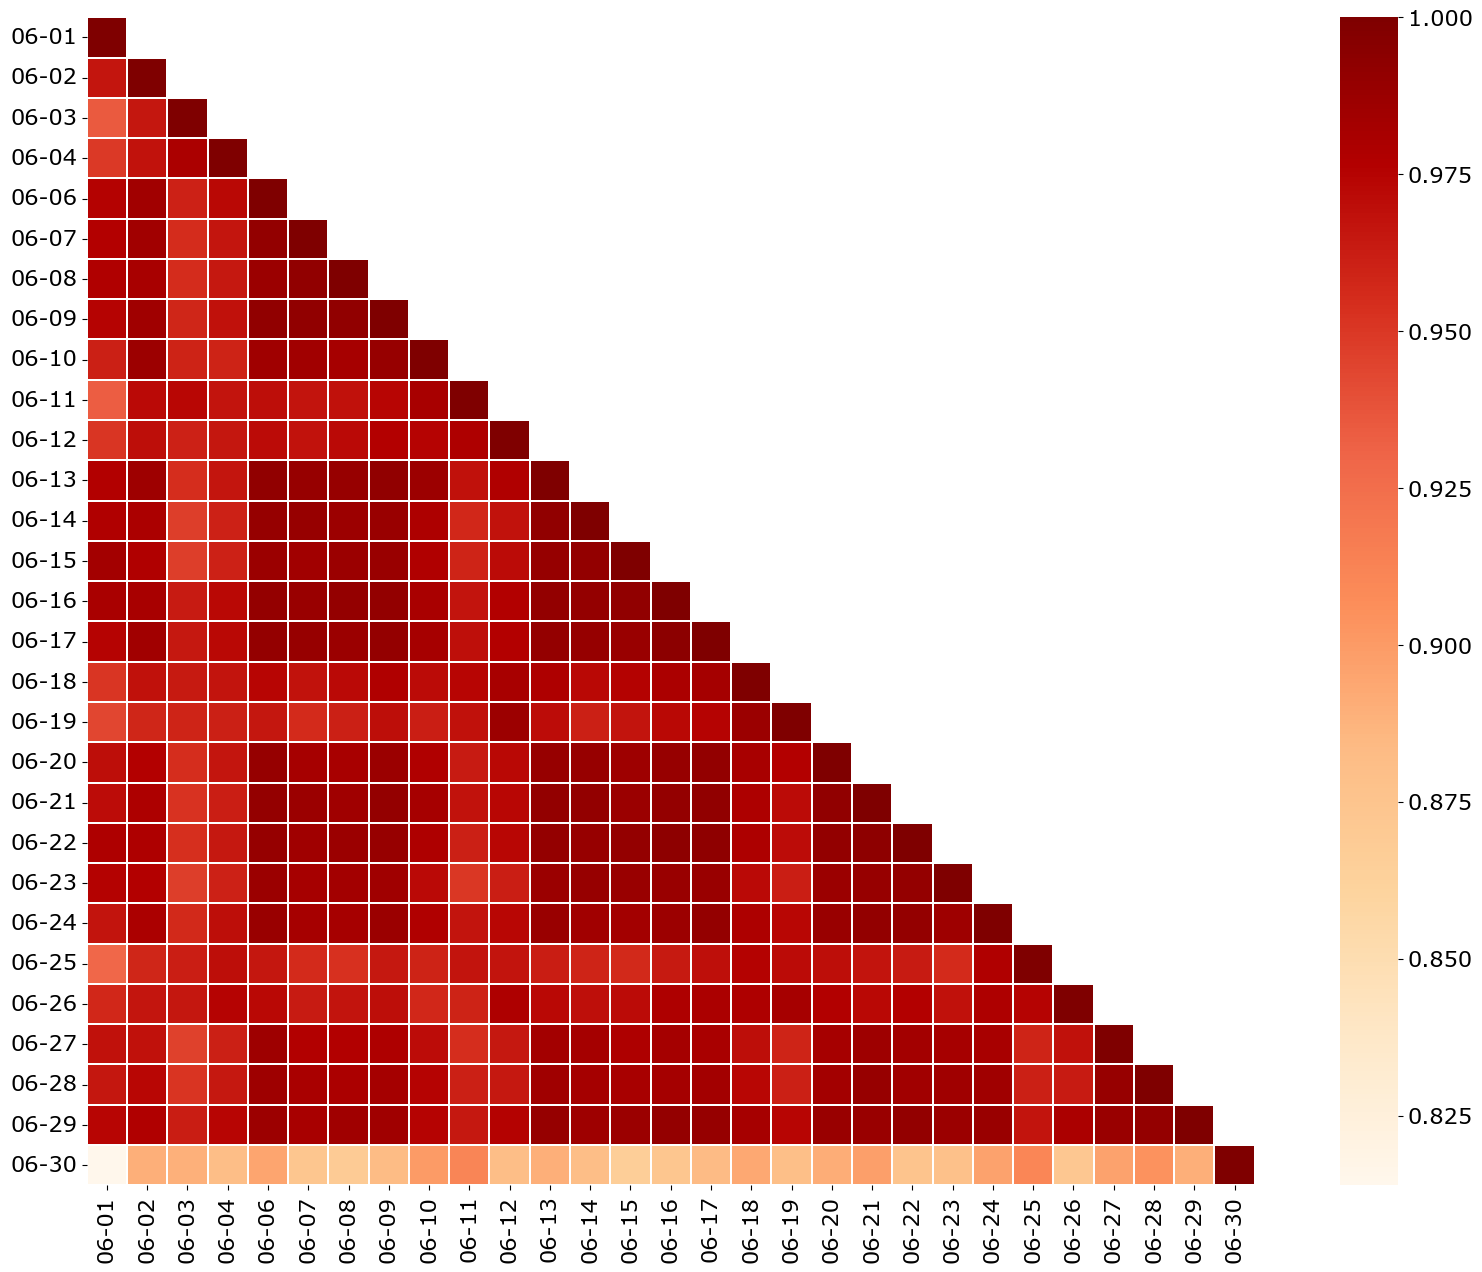

In [206]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
f, ax = plt.subplots(figsize=(20, 16)) 
mask = np.zeros_like(stre_coor)

for i in range(1,len(mask)):

  for j in range(0,i):

    mask[j][i] = True# 掩盖掉上面的三角形

sns.heatmap(stre_coor, annot=False,mask=mask,cmap="OrRd",linewidths=.01,square=True)

plt.subplots_adjust(left=.1, right=0.95, bottom=0.22, top=0.95)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=16,rotation=90)
plt.yticks(fontsize=16,rotation=0)
plt.show()#显示绘图内容

In [207]:
col = 0

date_stre = strength.iloc[:,col].to_frame().fillna(0)
index_stre = strength.index

In [ ]:

spaceMatrix = pd.DataFrame({},index=strength.index,columns=strength.index)
for province1 in spaceMatrix.index:
    for province2 in spaceMatrix.columns:
        if not np.isnan(spaceMatrix.loc[province1,province2]):
            continue
        #两地距离
        try:
            distance = h3.point_dist(h3.h3_to_geo(province1),h3.h3_to_geo(province2),'km')
            spaceMatrix.loc[province1,province2] = distance
            spaceMatrix.loc[province2,province1] = distance
        except:
            spaceMatrix.loc[province1,province2] = np.nan
            spaceMatrix.loc[province2,province1] = np.nan
            continue
        #地点相同，距离取无穷大，不然后面的倒数会报错
        if province1==province2:
            spaceMatrix.loc[province1,province2] = 10e17
spaceMatrix = spaceMatrix**-3

In [ ]:
moran = pd.DataFrame({},index=strength.columns,columns=['I','ZI_N'])
for col in range(len(strength.columns)):
    date_stre = strength.iloc[:,col].to_frame().fillna(0)
    result = moranI(spaceMatrix,date_stre)
    moran.loc[strength.columns[col],'I']=np.round(result['I']['value'],3)
    moran.loc[strength.columns[col],'ZI_N']=np.round(result['ZI_N']['value'],3)



In [ ]:
strength.iloc[:,col].to_frame().fillna(0)

In [18]:
strength.iloc[:,3].to_frame().fillna(0)

,Holiday
115745,False
115746,False
115747,False
115748,False
115749,False
...,...
140727,False
140728,False
140729,False
140730,False


In [163]:
moran

,I,ZI_N
date,,
06-01,0.355,15.16
06-02,0.328,14.016
06-03,0.324,13.813
06-04,0.347,14.805
06-06,0.346,14.741
06-07,0.352,15.009
06-08,0.353,15.048
06-09,0.349,14.873
06-10,0.332,14.144


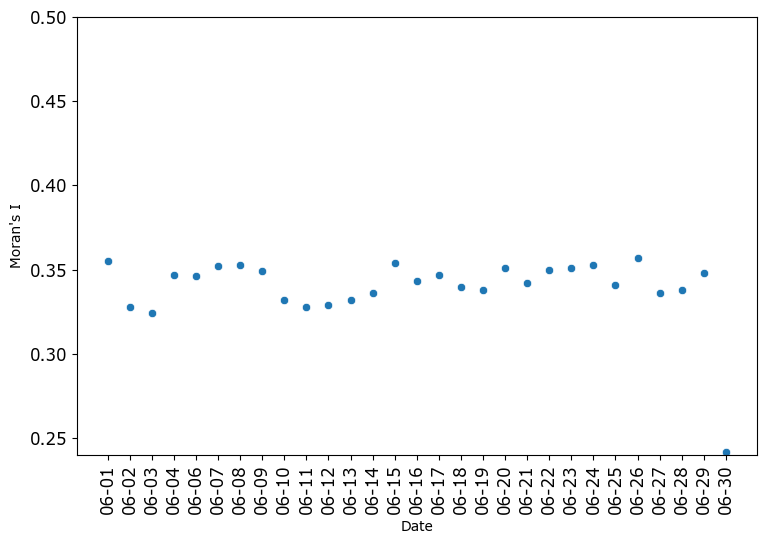

In [208]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
f, ax = plt.subplots(figsize=(8, 6)) 
plt.subplots_adjust(left=.1, right=0.95, bottom=0.22, top=0.95)

sns.scatterplot(x=moran.index,y=moran.I)
plt.xlabel('Date')
plt.ylabel('Moran\'s I')
plt.xticks(fontsize=12,rotation=90)
plt.yticks(fontsize=12)
plt.ylim(0.24,0.5)
plt.show()#显示绘图内容

In [165]:
moran.I.values

array([0.355, 0.328, 0.324, 0.347, 0.346, 0.352, 0.353, 0.349, 0.332,
       0.328, 0.329, 0.332, 0.336, 0.354, 0.343, 0.347, 0.34, 0.338,
       0.351, 0.342, 0.35, 0.351, 0.353, 0.341, 0.357, 0.336, 0.338,
       0.348, 0.242], dtype=object)

In [218]:
from statsmodels.tsa.stattools import adfuller
tem_result = adfuller(moran.I.values[:24])

In [219]:
tem_result


(-3.340893635328875,
 0.013146594625052127,
 0,
 23,
 {'1%': -3.7529275211638033,
  '5%': -2.998499866852963,
  '10%': -2.6389669754253307},
 -96.21850993627848)

In [220]:
alpha = 0.05
if tem_result[1] < alpha:  # p_value值大，无法拒接原假设,有可能单位根，需要T检验
    print("stationarity")
else:
    if tem_result[0] < tem_result[4]['5%']:  # 代表t检验的值小于5%,置信度为95%以上，这里还有'1%'和'10%'
        print("stationarity")  # 拒接原假设，无单位根，平稳的
    else:
        print("no_stationarity")


stationarity


In [232]:
from minepy import pstats, cstats
from cmcrameri import cm

sele_strength = all_strength.loc[(all_strength['date'].dt.month==6)]
fluc = sele_strength.groupby(['date']).agg({'strength_values':'describe'})
date_list = pd.date_range(start=fluc.index.min(),end=fluc.index.max(),freq='D')
hexagon = pd.crosstab(
    index=sele_strength['date'],
    columns=all_strength['hex_id'],
    values=all_strength['strength_values'],
    aggfunc='sum').reindex(index=date_list).fillna(0)
hexagon_data = np.array(hexagon)

mic_c, tic_c = cstats(hexagon_data.T,hexagon_data.T,alpha=9,c=15,est="mic_e")
mic = pd.DataFrame(data=mic_c,index=hexagon.columns.values,columns=hexagon.columns.values)


In [243]:

colors_hex = ['#1F77B3', '#FF7F0E', '#2CA02C', '#D62728',
              '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']


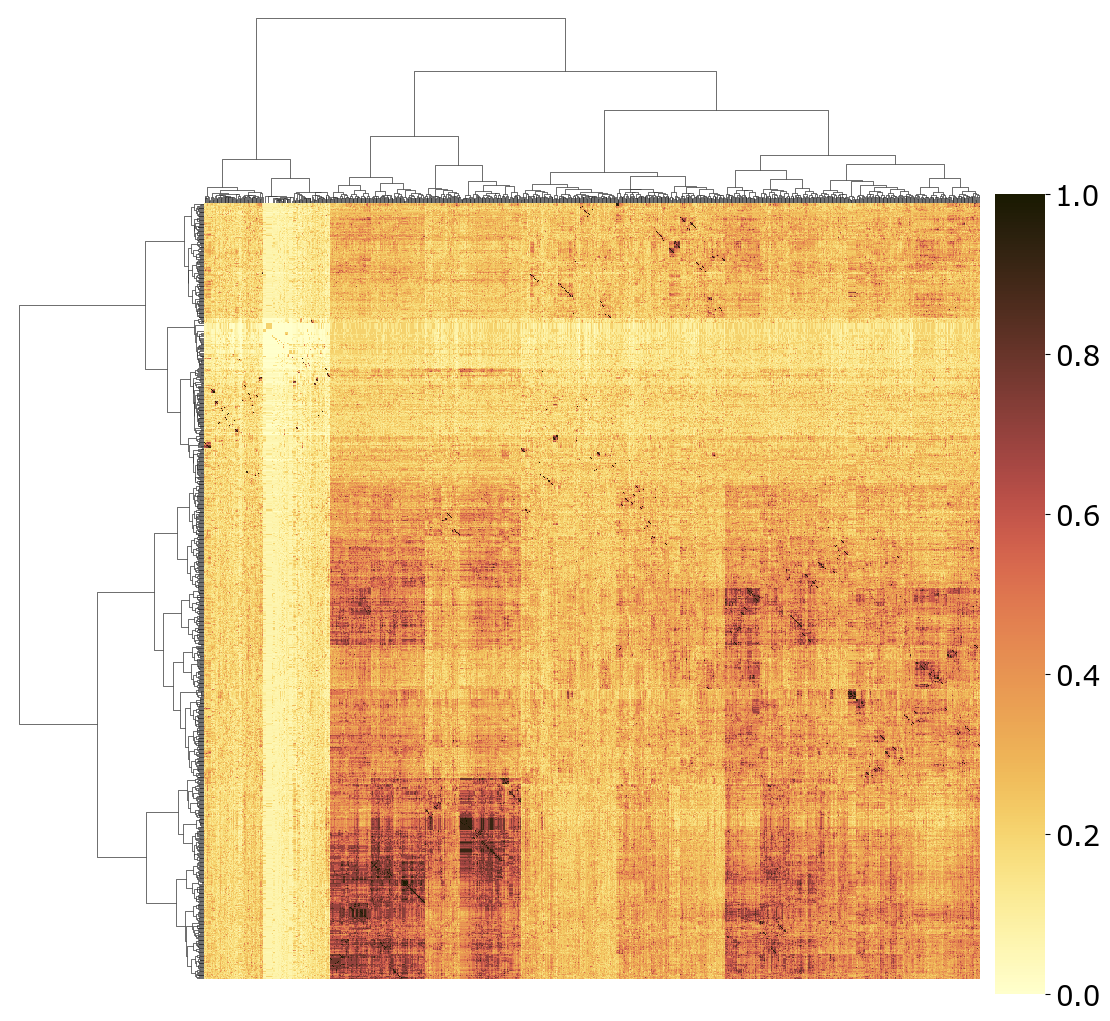

In [239]:
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.family']=['Verdana']
ax = sns.clustermap(
    data=mic, vmin=0, vmax=1, cmap=cm.lajolla, linecolor='#f1f1f1',
    method = 'ward', metric='euclidean',
    xticklabels=False, yticklabels=False)
ax.cax.set_position([1,0,0.05,0.8])
ax.cax.tick_params(labelsize=20)
plt.show()

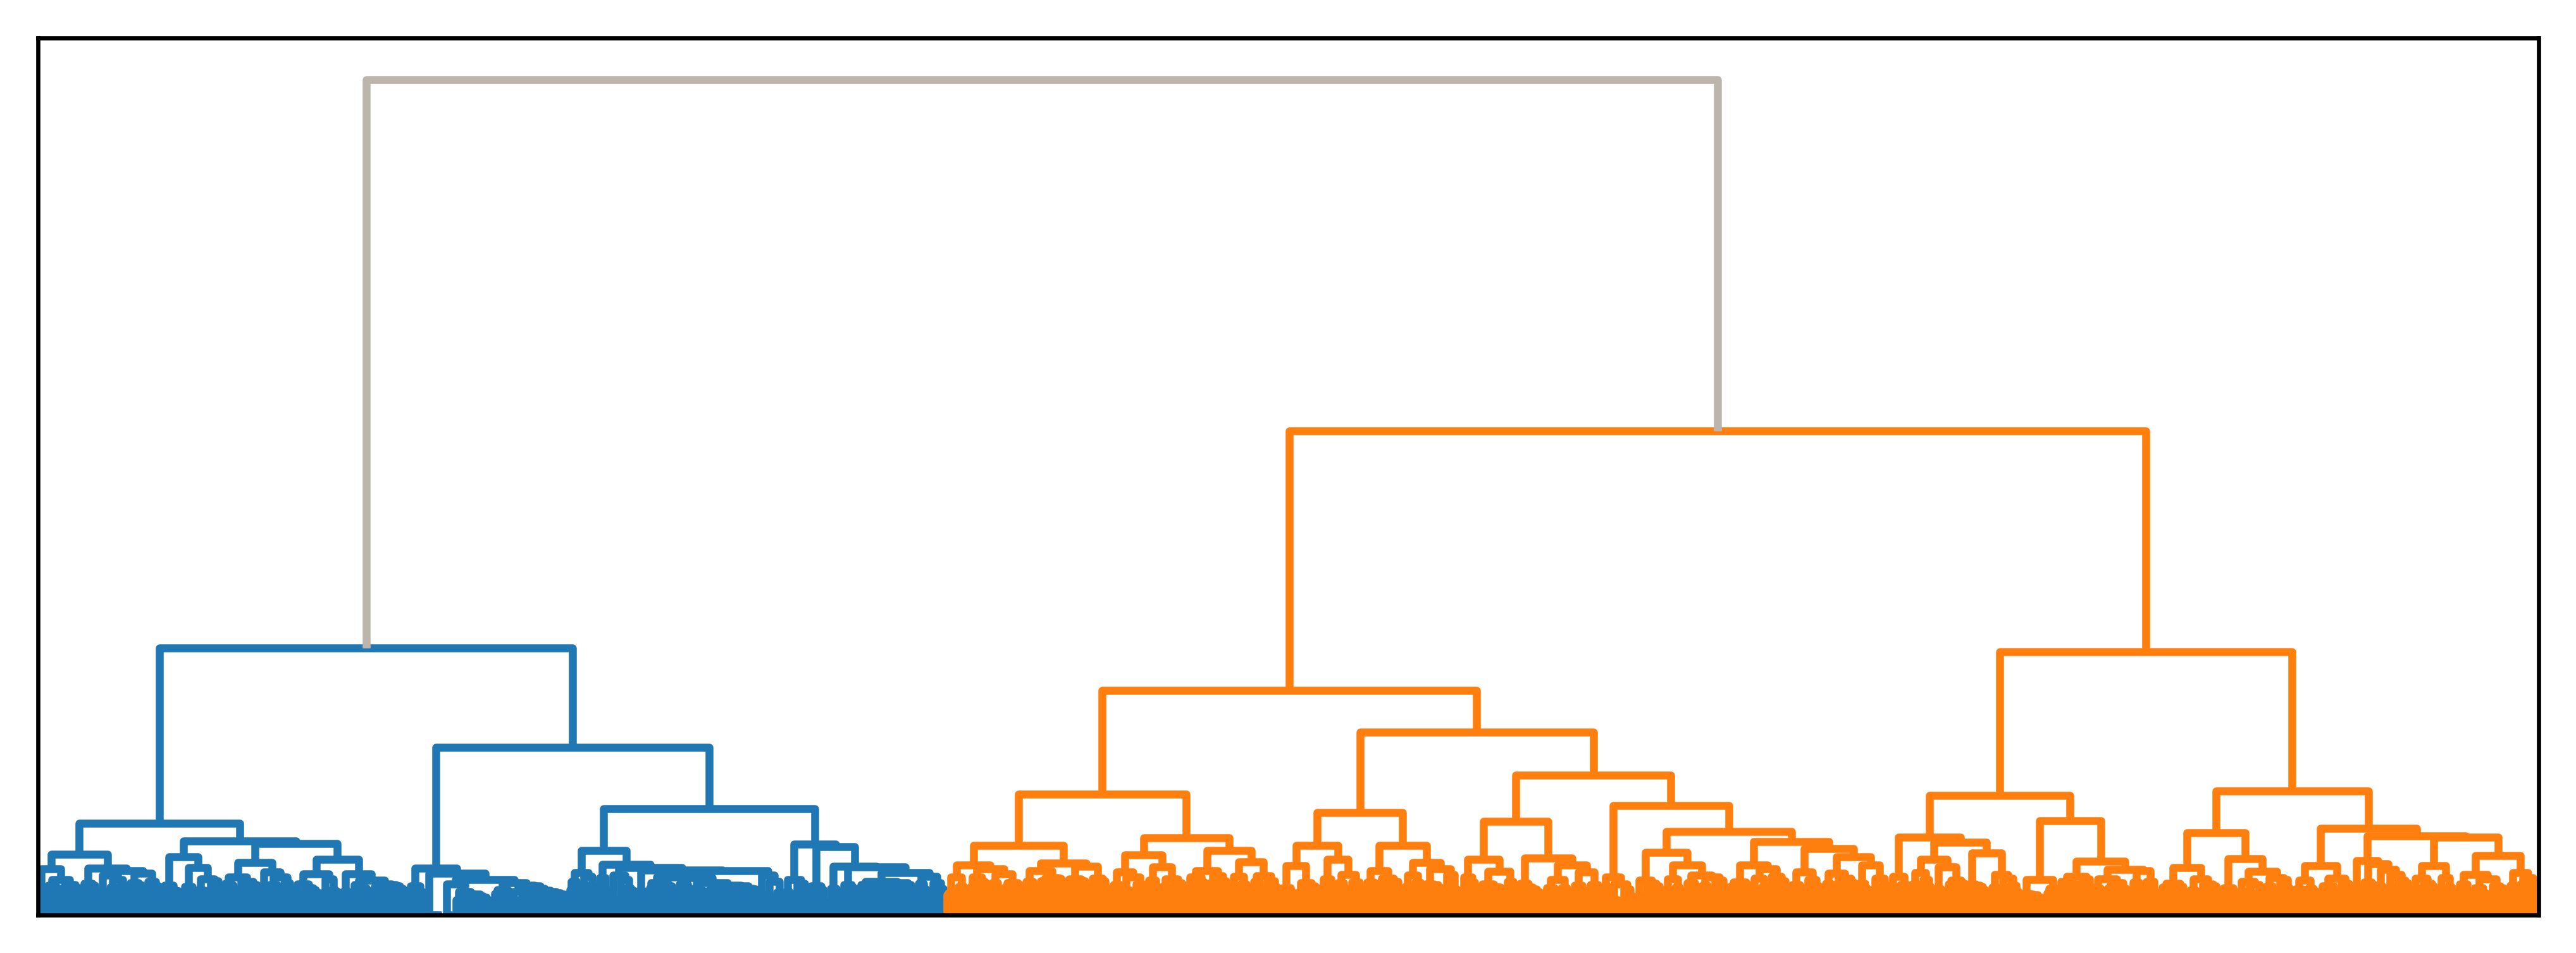

In [277]:
import scipy.cluster.hierarchy as sch
colors_hex = ['#1F77B3', '#FF7F0E', '#2CA02C', '#D62728',
              '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']
plt.figure(dpi=600,figsize=(8.5,3))

plt.rcParams['font.sans-serif'] = ['Verdana']
sch.set_link_color_palette(colors_hex)
thd = 25

#plt.axhline(y=thd,lw=1,ls="--",c="#393733")#添加水平直线
dendrogram = sch.dendrogram(
    sch.linkage(mic, method = 'ward',metric='euclidean'),
    labels=mic.index,above_threshold_color='#bbb5ac')

plt.xticks([])
plt.yticks([])
plt.show()


In [272]:
clustering = pd.DataFrame({
    "hexagon_id": dendrogram['ivl'],
    "category": dendrogram['leaves_color_list']
    })
clustering['Polygon'] = clustering['hexagon_id'].apply(lambda x: h3.h3_to_geo_boundary(x))


In [258]:
from h3 import h3
import folium
import folium.plugins

In [275]:
attr_anno = 'Map tiles by &copy; <a href="https://carto.com/attributions">CARTO</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>.'
map_tile = 'https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png'
cen_loc = [34.6412,119.234865]

In [274]:
city_map = folium.Map(
    location = cen_loc,
    zoom_start = 11,
    max_zoom = 16,
    min_zoom = 8,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)

#H3
H3_map = folium.map.FeatureGroup()
for row_index, row_data in clustering.iterrows():
    H3_map.add_child(
        folium.Polygon(
            row_data['Polygon'],
            color = row_data['category'],
            fill_color = row_data['category'],
            fill_opacity = 0.8,
            opacity = 0.2,
            fill = True
        )
    )
    
city_map.add_child(H3_map)

# 添加图例

# 显示地图
map_name = 'LYGCLUSTER.html'
map_path = os.path.join(work_path,map_name)
city_map.save(map_path)

In [ ]:
map_path